# Detection floor and the sensitivity–precision tradeoff

Six taxonomic profilers (Kraken2, Centrifuge, Centrifuger, Ganon2, Sourmash, Sylph) are evaluated on
their recovery of rare taxa in the ZymoBIOMICS D6331 mock, whose members span 14% down to 0.0001% in
staggered abundance. All analyses use the unified RefSeq database and pool the four D6331 libraries
(two PacBio HiFi, two ONT), evaluated at no detection threshold (value > 0) unless a sweep is shown.

This is a secondary analysis supporting the Discussion; it is not part of the core figure pipeline. It
reads the preprocessed detection CSVs from `analysis_prep.py` and writes its tables and figures to
`results/<TS>/auxiliary/sensitivity_floor/`.

The simulated datasets are not used here: at uniform 25x per-genome depth they contain no rare taxa,
so they cannot test a detection floor.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

# Anchor to the bakeoff root so the shared utils import works from any CWD.
BAKEOFF_ROOT = next((d for d in [Path.cwd(), *Path.cwd().parents]
                     if (d / 'config' / 'bakeoff_env.yaml').is_file()), None)
if BAKEOFF_ROOT is None:
    raise RuntimeError(f'Could not locate bakeoff/ root from {Path.cwd()}')
os.chdir(BAKEOFF_ROOT)
sys.path.insert(0, str(BAKEOFF_ROOT / 'scripts' / 'analysis'))

from utils.util import apply_taxid_synonyms
from utils.results import find_latest_analysis_prep_ts, save_csv, save_fig

# Configuration
SAVE              = True
RESULTS_ROOT      = BAKEOFF_ROOT / 'results'
TS                = find_latest_analysis_prep_ts(RESULTS_ROOT)   # or pin: TS = 'YYYYMMDD_HHMMSS'
PREP_DIR          = RESULTS_ROOT / 'metadata' / TS / 'analysis-prep'
DETECTION_DIR     = PREP_DIR / 'preprocessed' / 'detection'
GT_DIR            = PREP_DIR / 'ground_truth'
OUT_DIR           = RESULTS_ROOT / TS / 'auxiliary' / 'sensitivity_floor'

RANKS             = ['species', 'genus']
SYNONYM_TAXID_MAP = {1578: 2742598}            # match the main detection pipeline
SKETCH_TOOLS      = {'Sourmash', 'Sylph'}
TOOLS             = ['Centrifuge_unified', 'Centrifuger_unified', 'Kraken2_unified',
                     'Ganon2_unified', 'Sourmash_unified', 'Sylph_unified']
TOOL_ORDER        = ['Kraken2', 'Centrifuge', 'Centrifuger', 'Ganon2', 'Sourmash', 'Sylph']

# The four staggered D6331 libraries, all sharing zymoD6331_gt.csv (with abundance).
ZYMO_MOCKS = [
    ('ZymoMockD6331', 'pacbio', 'SRR13128013'),   # PacBio low input
    ('ZymoMockD6331', 'pacbio', 'SRR13128014'),   # PacBio standard input
    ('ZymoMockD6331', 'ont',    'D6331_Zymo'),     # ONT Zymo extraction
    ('ZymoMockD6331', 'ont',    'D6331_Qiagen'),   # ONT Qiagen extraction
]

# Shared per-tool palette (tab10 by base tool), matching the other bakeoff notebooks.
_TAB10 = plt.get_cmap('tab10')
TOOL_COLORS = {'Centrifuge': _TAB10(0), 'Centrifuger': _TAB10(1), 'Kraken2': _TAB10(2),
               'Ganon2': _TAB10(3), 'Sourmash': _TAB10(4), 'Sylph': _TAB10(5)}
def tool_color(tool):  return TOOL_COLORS.get(str(tool), (0.5, 0.5, 0.5, 1.0))
def tool_class(tool):  return 'sketch' if str(tool).split('_')[0] in SKETCH_TOOLS else 'classifier'
def is_sketch(base):   return base in SKETCH_TOOLS

# Figure house style
TITLE_KW = dict(fontsize=14, fontweight='bold', pad=12)
LABEL_FS = 12

def _clean_taxid(df):
    df = df.copy()
    df['taxid'] = pd.to_numeric(df['taxid'], errors='coerce').astype('Int64')
    return df.dropna(subset=['taxid']).reset_index(drop=True)

zgt = pd.read_csv(GT_DIR / 'zymoD6331_gt.csv')

print(f'ts:  {TS}')
print(f'out: {OUT_DIR}  (SAVE={SAVE})')

ts:  20260629_144812
out: /home/Users/pacbio_bakeoff/bakeoff/results/20260629_144812/auxiliary/sensitivity_floor  (SAVE=True)


## False negatives across the four mocks

For each (mock, rank, tool) we recompute presence at no threshold (value > 0) using the same clean,
rescale-to-percent, and synonym-collapse steps as `analysis_detection.ipynb`, then record every
ground-truth taxon the tool missed together with its true abundance.

In [2]:
fn_rows, floor_rows = [], []
for proj, tech, samp in ZYMO_MOCKS:
    fname, dataset = f'{proj}_{tech}_{samp}.csv', f'{tech}_{samp}'
    for rank in RANKS:
        g = _clean_taxid(zgt.query('rank == @rank')[['taxid', 'name', 'abundance']])
        g = apply_taxid_synonyms(g, abundance_col='abundance', synonyms=SYNONYM_TAXID_MAP,
                                 collapse=True, source_label=f'GT_{rank}')
        gt_taxids = set(g['taxid'].astype(int))
        ab        = dict(zip(g['taxid'].astype(int), pd.to_numeric(g['abundance'], errors='coerce')))
        name_of   = dict(zip(g['taxid'].astype(int), g['name']))

        for tool_db in TOOLS:
            p = DETECTION_DIR / tool_db / fname
            if not p.is_file():
                print(f'  skip: missing {tool_db}/{fname}')
                continue
            df = _clean_taxid(pd.read_csv(p).query('rank == @rank'))
            if df.empty:
                pred = set()
            else:
                df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0.0)
                df = apply_taxid_synonyms(df, abundance_col='value', synonyms=SYNONYM_TAXID_MAP,
                                          collapse=True, source_label=f'{tool_db}_{rank}')
                pred = set(df.loc[df['value'] > 0, 'taxid'].dropna().astype(int))

            recovered = gt_taxids & pred
            base = tool_db.replace('_unified', '')
            for tid in sorted(gt_taxids - pred):
                fn_rows.append(dict(dataset=dataset, rank=rank, tool=base, tool_class=tool_class(tool_db),
                                    taxid=tid, name=name_of.get(tid),
                                    true_abundance=float(ab.get(tid, np.nan))))
            rec_ab = [ab[t] for t in recovered if pd.notna(ab.get(t))]
            floor_rows.append(dict(dataset=dataset, rank=rank, tool=base, tool_class=tool_class(tool_db),
                                   n_recovered=len(recovered), n_truth=len(gt_taxids),
                                   min_recovered_abundance=(min(rec_ab) if rec_ab else np.nan)))

fn_long, floor_long = pd.DataFrame(fn_rows), pd.DataFrame(floor_rows)
print(f'{len(fn_long)} false-negative events across {len(ZYMO_MOCKS)} mocks x {len(TOOLS)} tools x {len(RANKS)} ranks')

[Synonyms:Centrifuge_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuger_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Kraken2_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Centrifuge_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
[Synonyms:Kraken2_unified_genus] 1 taxids replaced (examples: {np.int64(1578): 2742598})
25 false-negative events across 4 mocks x 6 tools x 2 ranks


## Summary tables

In [3]:
TIER_BINS   = [-1, 0.001, 0.1, 2, 100]
TIER_LABELS = ['<=0.001%', '0.001-0.1%', '0.1-2%', '>2%']

for rank in RANKS:
    print(f'rank: {rank}')
    sub = fn_long.query('rank == @rank')
    if sub.empty:
        print('  no false negatives across the four mocks.')
    else:
        per_tool = (sub.groupby(['tool_class', 'tool']).size()
                       .rename('n_FN').reset_index().sort_values(['tool_class', 'n_FN']))
        display(per_tool)

        tiers   = pd.cut(sub['true_abundance'], TIER_BINS, labels=TIER_LABELS)
        by_tier = sub.assign(tier=tiers).pivot_table(index='tier', columns='tool_class',
                             values='taxid', aggfunc='count', fill_value=0, observed=False)
        display(by_tier)

        per_taxon = (sub.groupby(['tool_class', 'tool', 'taxid', 'name', 'true_abundance'])
                        .size().rename('n_mocks_missed').reset_index()
                        .sort_values(['tool_class', 'tool', 'true_abundance']))
        display(per_taxon)

        save_csv(per_tool,  OUT_DIR / f'fn_per_tool_{rank}.csv',  SAVE, index=False)
        save_csv(by_tier,   OUT_DIR / f'fn_by_tier_{rank}.csv',   SAVE, index=True)
        save_csv(per_taxon, OUT_DIR / f'fn_per_taxon_{rank}.csv', SAVE, index=False)

    # Detection floor: lowest true abundance each tool still recovers, summarised over the 4 mocks.
    fl = floor_long.query('rank == @rank')
    floor_tool = (fl.groupby(['tool_class', 'tool'])
                    .agg(worst_floor=('min_recovered_abundance', 'max'),
                         best_floor=('min_recovered_abundance', 'min'),
                         mean_recovered=('n_recovered', 'mean'), n_truth=('n_truth', 'first'))
                    .reset_index().sort_values(['tool_class', 'tool']))
    display(floor_tool)
    save_csv(floor_tool, OUT_DIR / f'detection_floor_{rank}.csv', SAVE, index=False)

rank: species


,tool_class,tool,n_FN
0,classifier,Centrifuger,1
2,classifier,Kraken2,1
1,classifier,Ganon2,2
3,sketch,Sourmash,5
4,sketch,Sylph,6


tool_class,classifier,sketch
tier,,
<=0.001%,4,11
0.001-0.1%,0,0
0.1-2%,0,0
>2%,0,0


,tool_class,tool,taxid,name,true_abundance,n_mocks_missed
0,classifier,Centrifuger,1502,Clostridium perfringens,0.0001,1
1,classifier,Ganon2,1502,Clostridium perfringens,0.0001,2
2,classifier,Kraken2,1502,Clostridium perfringens,0.0001,1
4,sketch,Sourmash,1502,Clostridium perfringens,0.0001,4
3,sketch,Sourmash,1351,Enterococcus faecalis,0.0010,1
6,sketch,Sylph,1502,Clostridium perfringens,0.0001,4
5,sketch,Sylph,1351,Enterococcus faecalis,0.0010,2


,tool_class,tool,worst_floor,best_floor,mean_recovered,n_truth
0,classifier,Centrifuge,0.0001,0.0001,17.00,17
1,classifier,Centrifuger,0.0010,0.0001,16.75,17
2,classifier,Ganon2,0.0010,0.0001,16.50,17
3,classifier,Kraken2,0.0010,0.0001,16.75,17
4,sketch,Sourmash,0.0100,0.0010,15.75,17
5,sketch,Sylph,0.0100,0.0010,15.50,17


rank: genus


,tool_class,tool,n_FN
0,classifier,Ganon2,1
1,sketch,Sourmash,4
2,sketch,Sylph,5


tool_class,classifier,sketch
tier,,
<=0.001%,1,9
0.001-0.1%,0,0
0.1-2%,0,0
>2%,0,0


,tool_class,tool,taxid,name,true_abundance,n_mocks_missed
0,classifier,Ganon2,1485,Clostridium,0.0001,1
1,sketch,Sourmash,1485,Clostridium,0.0001,4
3,sketch,Sylph,1485,Clostridium,0.0001,4
2,sketch,Sylph,1350,Enterococcus,0.0010,1


,tool_class,tool,worst_floor,best_floor,mean_recovered,n_truth
0,classifier,Centrifuge,0.0001,0.0001,17.00,17
1,classifier,Centrifuger,0.0001,0.0001,17.00,17
2,classifier,Ganon2,0.0010,0.0001,16.75,17
3,classifier,Kraken2,0.0001,0.0001,17.00,17
4,sketch,Sourmash,0.0010,0.0010,16.00,17
5,sketch,Sylph,0.0100,0.0010,15.75,17


## Rare-tier detection matrix (supplementary table)

Detection of the low-abundance members (abundance <= 0.1%): one row per tool, one column per
species, each cell the number of the four mocks in which the species was detected at no threshold.
Written to CSV only.

In [4]:
RARE_MAX = 0.1
n_mocks  = floor_long.query('rank == "species"').groupby('tool')['dataset'].nunique()
miss     = (fn_long.query('rank == "species"')
            .groupby(['tool', 'taxid']).size().rename('missed').reset_index())

gt_sp = _clean_taxid(zgt.query('rank == "species"')[['taxid', 'name', 'abundance']])
gt_sp = apply_taxid_synonyms(gt_sp, abundance_col='abundance', synonyms=SYNONYM_TAXID_MAP,
                             collapse=True, source_label='GT_species')
gt_sp['taxid'] = gt_sp['taxid'].astype(int)

rows = []
for tool in TOOL_ORDER:
    nm = int(n_mocks.get(tool, 0))
    for _, g in gt_sp.query('abundance <= @RARE_MAX').iterrows():
        tid = int(g['taxid'])
        m   = miss.query('tool == @tool and taxid == @tid')['missed']
        rows.append(dict(tool=tool, name=g['name'], abundance=float(g['abundance']),
                         detected=nm - (int(m.iloc[0]) if len(m) else 0), n_mocks=nm))
rec = pd.DataFrame(rows)

rec['col']  = rec['name'] + ' (' + rec['abundance'].map(lambda a: f'{a:g}') + '%)'
rec['cell'] = rec['detected'].astype(str) + '/' + rec['n_mocks'].astype(str)
col_order = (rec[['col', 'abundance']].drop_duplicates()
             .sort_values('abundance', ascending=False)['col'].tolist())
mat = (rec.pivot(index='tool', columns='col', values='cell')
          .reindex(index=TOOL_ORDER, columns=col_order))
mat.index.name = 'Tool (unified)'
display(mat)
save_csv(mat, OUT_DIR / 'rare_tier_detection_matrix.csv', SAVE, index=True)

col,Methanobrevibacter smithii (0.1%),Salmonella enterica (0.01%),Enterococcus faecalis (0.001%),Clostridium perfringens (0.0001%)
Tool (unified),,,,
Kraken2,4/4,4/4,4/4,3/4
Centrifuge,4/4,4/4,4/4,4/4
Centrifuger,4/4,4/4,4/4,3/4
Ganon2,4/4,4/4,4/4,2/4
Sourmash,4/4,4/4,3/4,0/4
Sylph,4/4,4/4,2/4,0/4


## Sensitivity–precision tradeoff

Recovery of rare taxa is accompanied by false positives. The cells below quantify both sides on the
four mocks. The first builds per-(tool, mock) species value vectors that the tradeoff, sweep, and
platform cells reuse.

In [5]:
MOCK_LIBS = [(tech, samp) for _proj, tech, samp in ZYMO_MOCKS]

def _mock_values(tool_db, tech, samp, rank='species'):
    # taxid -> rescaled %-of-total value for one (tool, mock), synonym-collapsed.
    p = DETECTION_DIR / tool_db / f'ZymoMockD6331_{tech}_{samp}.csv'
    if not p.is_file():
        return {}
    df = _clean_taxid(pd.read_csv(p).query('rank == @rank'))
    if df.empty:
        return {}
    df['value'] = pd.to_numeric(df['value'], errors='coerce').fillna(0.0)
    df = apply_taxid_synonyms(df, abundance_col='value', synonyms=SYNONYM_TAXID_MAP,
                              collapse=True, source_label=tool_db)
    return dict(zip(df['taxid'].astype(int), df['value']))

GT_SP = _clean_taxid(zgt.query('rank == "species"')[['taxid', 'name', 'abundance']])
GT_SP = apply_taxid_synonyms(GT_SP, abundance_col='abundance', synonyms=SYNONYM_TAXID_MAP,
                             collapse=True, source_label='GT_species')
GT_SP['taxid'] = GT_SP['taxid'].astype(int)
GT_TAX   = set(GT_SP['taxid'])
GT_AB    = dict(zip(GT_SP['taxid'], pd.to_numeric(GT_SP['abundance'], errors='coerce')))
RARE_TAX = {tid for tid, a in GT_AB.items() if a <= 0.1}
GT_NAME  = dict(zip(GT_SP['taxid'], GT_SP['name']))

VALUES = {(t, tech, samp): _mock_values(t, tech, samp)
          for t in TOOLS for (tech, samp) in MOCK_LIBS}
print(f'{len(TOOLS)} tools x {len(MOCK_LIBS)} mocks; {len(GT_TAX)} GT species, {len(RARE_TAX)} rare-tier (<=0.1%)')

6 tools x 4 mocks; 17 GT species, 4 rare-tier (<=0.1%)


### False positives vs true positives at no threshold

Mean per-mock counts, with the rare-tier recovery called out. Tools are colored by the shared
palette; marker shape encodes class.

,tool_class,tool,FP,TP,rareTP_of_4
0,classifier,Centrifuge,1794.2,17.0,4.00
1,classifier,Centrifuger,342.2,16.8,3.75
2,classifier,Ganon2,80.0,16.5,3.50
3,classifier,Kraken2,511.2,16.8,3.75
4,sketch,Sourmash,13.0,15.8,2.75
5,sketch,Sylph,8.8,15.5,2.50


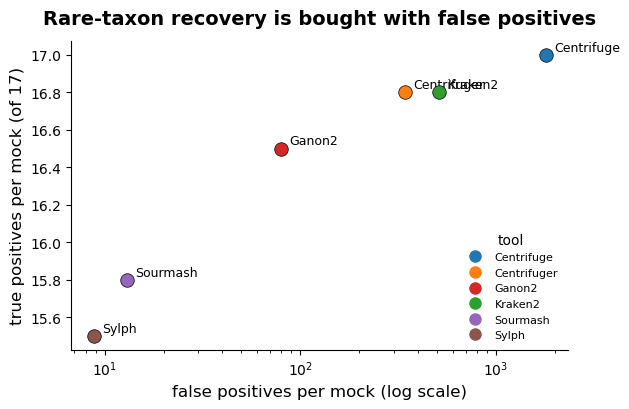

In [6]:
rows = []
for t in TOOLS:
    for tech, samp in MOCK_LIBS:
        pred = {tid for tid, val in VALUES[(t, tech, samp)].items() if val > 0}
        rows.append(dict(tool=t.replace('_unified', ''), tool_class=tool_class(t),
                         FP=len(pred - GT_TAX), TP=len(pred & GT_TAX),
                         rareTP=len((pred & GT_TAX) & RARE_TAX)))
agg = (pd.DataFrame(rows).groupby(['tool_class', 'tool'])
         .agg(FP=('FP', 'mean'), TP=('TP', 'mean'), rareTP=('rareTP', 'mean'))
         .reset_index().sort_values(['tool_class', 'tool']))
agg['FP'] = agg['FP'].round(1); agg['TP'] = agg['TP'].round(1); agg['rareTP'] = agg['rareTP'].round(2)
agg = agg.rename(columns={'rareTP': f'rareTP_of_{len(RARE_TAX)}'})
display(agg)
save_csv(agg, OUT_DIR / 'tradeoff_no_threshold.csv', SAVE, index=False)

fig, ax = plt.subplots(figsize=(6.4, 4.2))
for _, r in agg.iterrows():
    ax.scatter(r['FP'], r['TP'], s=95, color=tool_color(r['tool']),
               marker='o', edgecolor='black', linewidth=0.5, zorder=3)
    ax.annotate(r['tool'], (r['FP'], r['TP']), xytext=(6, 3), textcoords='offset points', fontsize=9)
ax.set_xscale('log')
ax.set_xlabel('false positives per mock (log scale)', fontsize=LABEL_FS)
ax.set_ylabel(f'true positives per mock (of {len(GT_TAX)})', fontsize=LABEL_FS)
ax.set_title('Rare-taxon recovery is bought with false positives', **TITLE_KW)
tool_handles = [Line2D([], [], marker='o', ls='', color=tool_color(t), label=t, markersize=8)
                for t in agg['tool']]
ax.legend(handles=tool_handles, frameon=False, loc='lower right', fontsize=8, title='tool')
for s in ('top', 'right'): ax.spines[s].set_visible(False)
fig.tight_layout(); save_fig(fig, OUT_DIR / 'tradeoff_no_threshold.png', SAVE, dpi=200); plt.show()

### Operating characteristic across the threshold sweep

Two views of the same sweep over thresholds {0, 1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.5, 1}%. (a) Precision-recall plane
with iso-F1 curves; the open circle marks threshold 0 and the arrowhead marks 1%. (b) F1 vs
threshold, with a band spanning min to max across the four mocks (mostly the PacBio/ONT difference).
Lines are colored by tool.

Beyond ~0.1% the threshold begins excluding the mock's genuine low-abundance members (the recall ceiling falls from 0.82 at 0.1% to 0.77 at 0.2-1%), so the F1 decline at higher thresholds reflects the staggered community design rather than tool degradation. F1 peaks near 0.1-0.2%, confirming it as a sensible operating point.

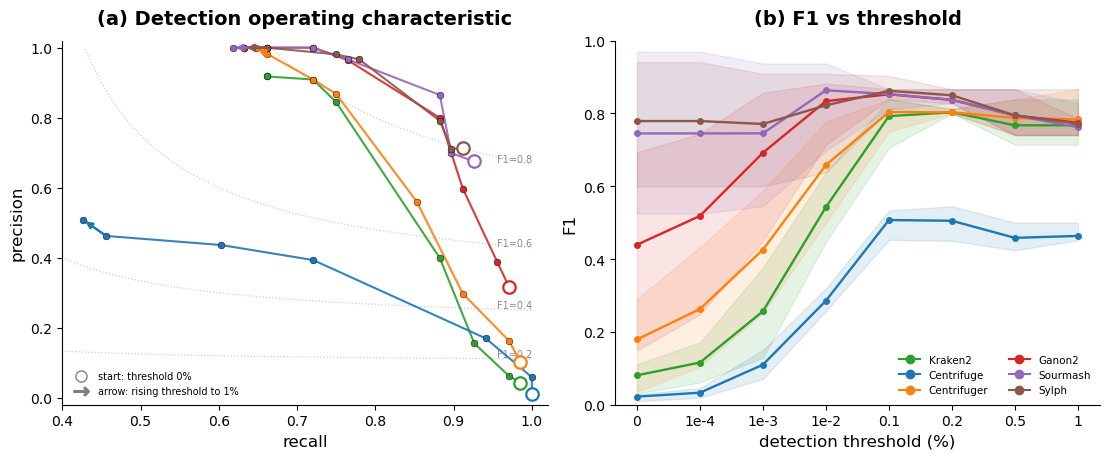

In [7]:
SWEEP = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 2e-1, 5e-1, 1.0]

def _prf(pred, gt):
    TP, FP, FN = len(pred & gt), len(pred - gt), len(gt - pred)
    P = TP / (TP + FP) if TP + FP else 0.0
    R = TP / (TP + FN) if TP + FN else 0.0
    return P, R, (2 * P * R / (P + R) if P + R else 0.0)

rows = []
for t in TOOLS:
    base = t.replace('_unified', '')
    for thr in SWEEP:
        for tech, samp in MOCK_LIBS:
            pred = {tid for tid, val in VALUES[(t, tech, samp)].items()
                    if (val > 0 if thr == 0 else val >= thr)}
            P, R, F = _prf(pred, GT_TAX)
            rows.append(dict(tool=base, tool_class=tool_class(t), threshold=thr,
                             precision=P, recall=R, F1=F))
agg2 = (pd.DataFrame(rows).groupby(['tool', 'tool_class', 'threshold'])
        .agg(precision=('precision', 'mean'), recall=('recall', 'mean'),
             F1=('F1', 'mean'), F1_min=('F1', 'min'), F1_max=('F1', 'max'))
        .reset_index())
save_csv(agg2, OUT_DIR / 'pr_sweep_detail.csv', SAVE, index=False)

fig, (axA, axB) = plt.subplots(1, 2, figsize=(11.2, 4.7))

# Panel A: precision-recall plane with iso-F1 curves
rr = np.linspace(0.001, 1.0, 500)
for f in (0.2, 0.4, 0.6, 0.8):
    pp = np.where(2 * rr - f > 0, f * rr / (2 * rr - f), np.nan)
    ok = (2 * rr - f > 0) & (pp >= 0) & (pp <= 1.0)
    axA.plot(rr[ok], pp[ok], ls=':', color='0.8', lw=0.9, zorder=1)
    if ok.any():
        axA.text(rr[ok][-1], min(pp[ok][-1], 0.985), f'F1={f:g}', color='0.55',
                 fontsize=7, ha='right', va='bottom')
for tool in TOOL_ORDER:
    g   = agg2[agg2.tool == tool].sort_values('threshold')
    col = tool_color(tool)
    axA.plot(g.recall, g.precision, '-', color=col, lw=1.5, alpha=0.9, zorder=3)
    axA.scatter(g.recall, g.precision, s=24, color=col, edgecolor='black', linewidth=0.3, zorder=4)
    axA.scatter([g.iloc[0].recall], [g.iloc[0].precision], s=80,
                facecolor='white', edgecolor=col, linewidth=1.6, zorder=6)
    axA.annotate('', xy=(g.iloc[-1].recall, g.iloc[-1].precision),
                 xytext=(g.iloc[-2].recall, g.iloc[-2].precision),
                 arrowprops=dict(arrowstyle='-|>', color=col, lw=1.6), zorder=6)
axA.set_xlim(0.4, 1.02); axA.set_ylim(-0.02, 1.02)
axA.set_xlabel('recall', fontsize=LABEL_FS); axA.set_ylabel('precision', fontsize=LABEL_FS)
axA.set_title('(a) Detection operating characteristic', **TITLE_KW)
axA.legend(handles=[Line2D([], [], marker='o', ls='', markerfacecolor='white',
                           markeredgecolor='gray', markersize=8, label='start: threshold 0%'),
                    Line2D([], [], marker=r'$\rightarrow$', ls='', color='gray',
                           markersize=11, label='arrow: rising threshold to 1%')],
           fontsize=7, frameon=False, loc='lower left')
for s in ('top', 'right'): axA.spines[s].set_visible(False)

# Panel B: F1 vs threshold, with a min-max band across the four mocks
xpos = list(range(len(SWEEP)))
xmap = dict(zip(SWEEP, xpos))
for tool in TOOL_ORDER:
    g   = agg2[agg2.tool == tool].sort_values('threshold')
    col = tool_color(tool)
    axB.fill_between([xmap[t] for t in g.threshold], g.F1_min, g.F1_max, color=col, alpha=0.12, zorder=1)
    axB.plot([xmap[t] for t in g.threshold], g.F1, '-',
             color=col, marker='o', ms=4, lw=1.7, zorder=3)
axB.set_xticks(xpos); axB.set_xticklabels(['0', '1e-4', '1e-3', '1e-2', '0.1', '0.2', '0.5', '1'])
axB.set_xlabel('detection threshold (%)', fontsize=LABEL_FS); axB.set_ylabel('F1', fontsize=LABEL_FS)
axB.set_ylim(0, 1)
axB.set_title('(b) F1 vs threshold', **TITLE_KW)
tool_handles = [Line2D([], [], color=tool_color(t), marker='o', ls='-', label=t) for t in TOOL_ORDER]
axB.legend(handles=tool_handles, fontsize=7.5, ncol=2, frameon=False, loc='lower right')
for s in ('top', 'right'): axB.spines[s].set_visible(False)

fig.tight_layout(); save_fig(fig, OUT_DIR / 'pr_sweep_2panel.png', SAVE, dpi=200); plt.show()

### Rare-tier detection by platform

Each rare-tier cell split as PacBio k/2 and ONT k/2, to check whether misses concentrate on the
higher-error ONT libraries.

In [8]:
PB_LIBS  = [(te, sa) for te, sa in MOCK_LIBS if te == 'pacbio']
ONT_LIBS = [(te, sa) for te, sa in MOCK_LIBS if te == 'ont']
RARE_ORDER = sorted(RARE_TAX, key=lambda tid: -GT_AB[tid])

def _hits(tool_db, libs, tid):
    return sum(1 for te, sa in libs if VALUES[(tool_db, te, sa)].get(tid, 0.0) > 0)

rows = []
for t in TOOLS:
    row = {'Tool (unified)': t.replace('_unified', '')}
    for tid in RARE_ORDER:
        row[f'{GT_NAME[tid]} ({GT_AB[tid]:g}%)'] = (
            f'{_hits(t, PB_LIBS, tid)}/{len(PB_LIBS)} . {_hits(t, ONT_LIBS, tid)}/{len(ONT_LIBS)}')
    rows.append(row)
split = pd.DataFrame(rows).set_index('Tool (unified)').reindex(TOOL_ORDER)
display(split)
save_csv(split, OUT_DIR / 'rare_tier_detection_by_platform.csv', SAVE, index=True)

,Methanobrevibacter smithii (0.1%),Salmonella enterica (0.01%),Enterococcus faecalis (0.001%),Clostridium perfringens (0.0001%)
Tool (unified),,,,
Kraken2,2/2 . 2/2,2/2 . 2/2,2/2 . 2/2,1/2 . 2/2
Centrifuge,2/2 . 2/2,2/2 . 2/2,2/2 . 2/2,2/2 . 2/2
Centrifuger,2/2 . 2/2,2/2 . 2/2,2/2 . 2/2,1/2 . 2/2
Ganon2,2/2 . 2/2,2/2 . 2/2,2/2 . 2/2,1/2 . 1/2
Sourmash,2/2 . 2/2,2/2 . 2/2,2/2 . 1/2,0/2 . 0/2
Sylph,2/2 . 2/2,2/2 . 2/2,1/2 . 1/2,0/2 . 0/2
